In [ ]:
import numpy as np
from partimorph import (
    analyze_mask,
    create_circle_mask,
    create_ellipse_mask,
    create_rectangle_mask,
    create_square_mask,
    create_triangle_mask,
    create_pentagon_mask,
    create_star_mask,
    plot_analysis_results,
)

### Analysis and Sorting by Sphericity
All masks are analyzed and then sorted by their **Sphericity** value in descending order.
The plot title now includes the **Aspect Ratio** (Major/Minor) from ellipse fitting.

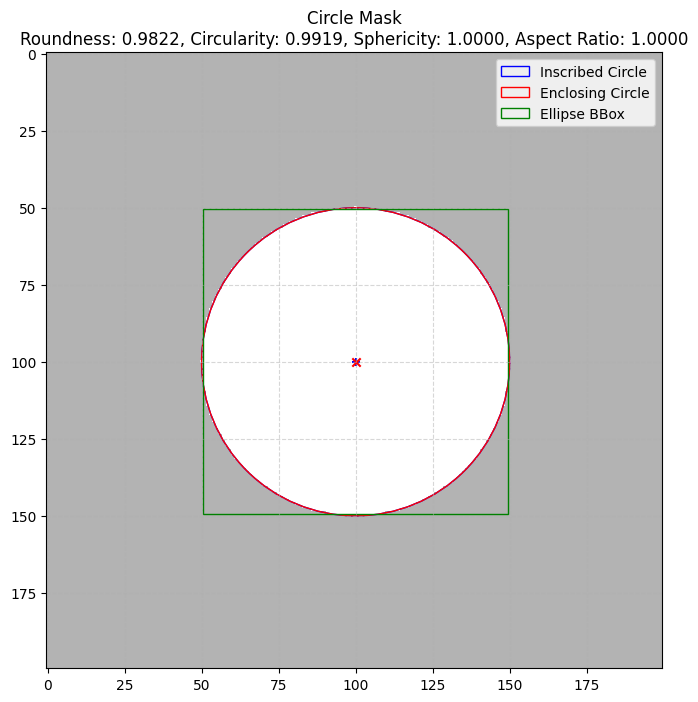

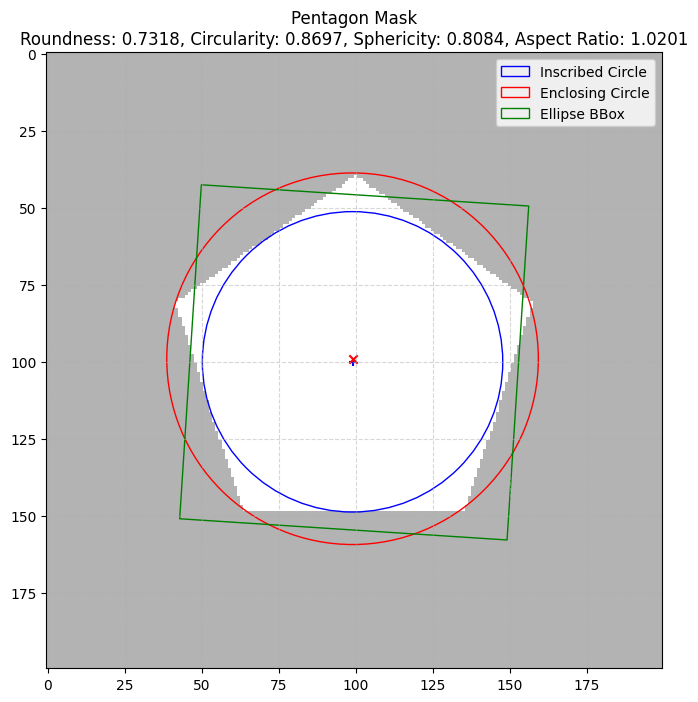

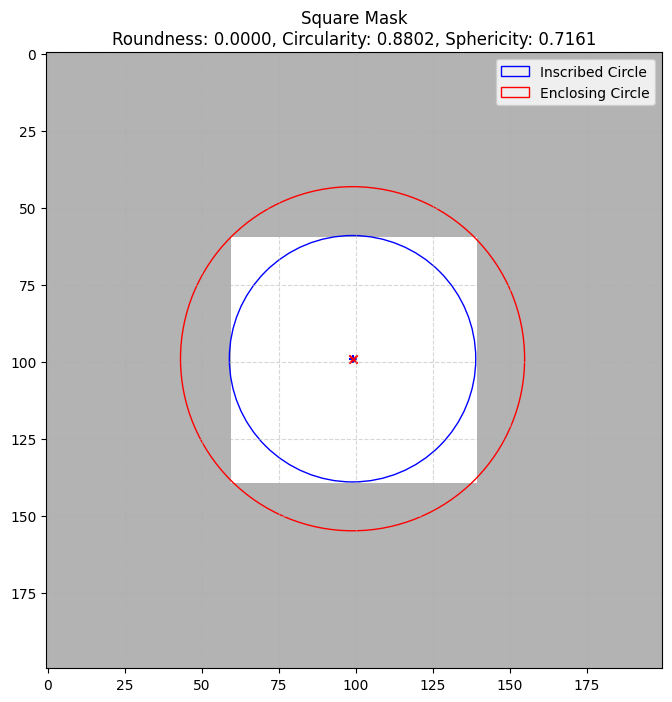

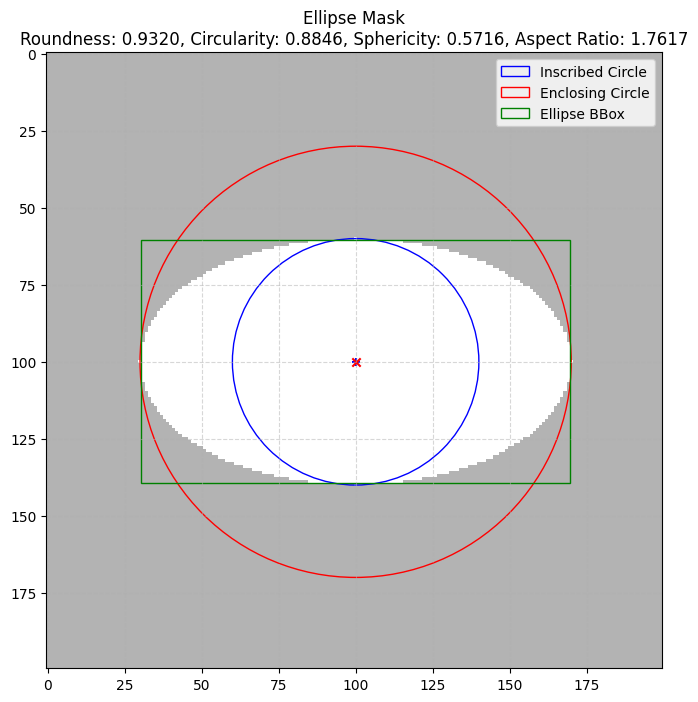

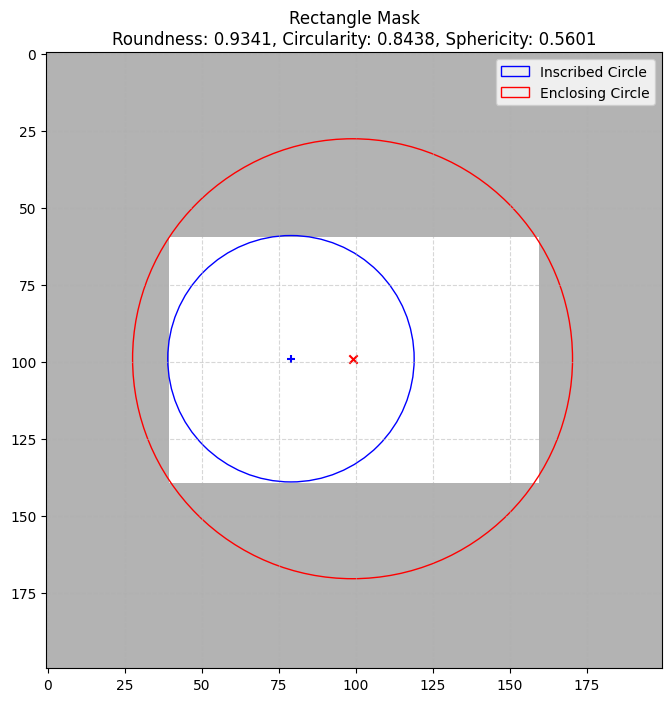

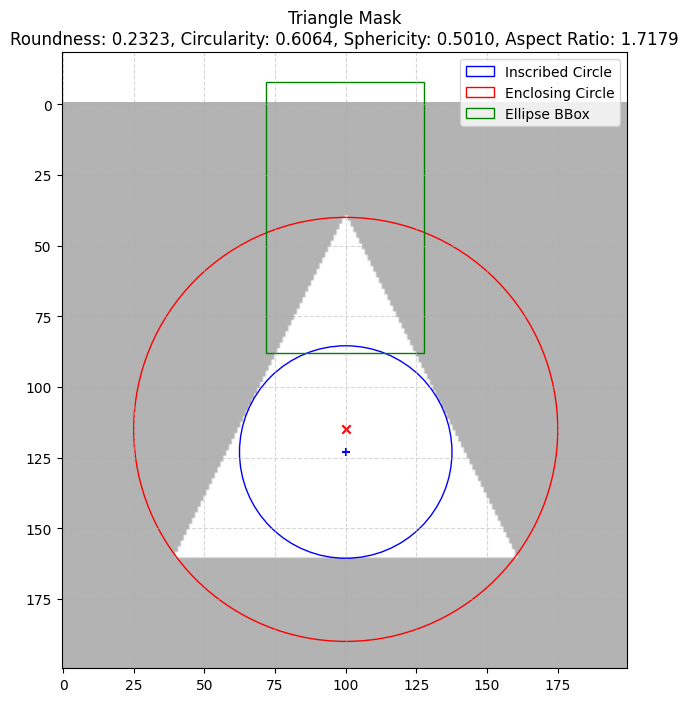

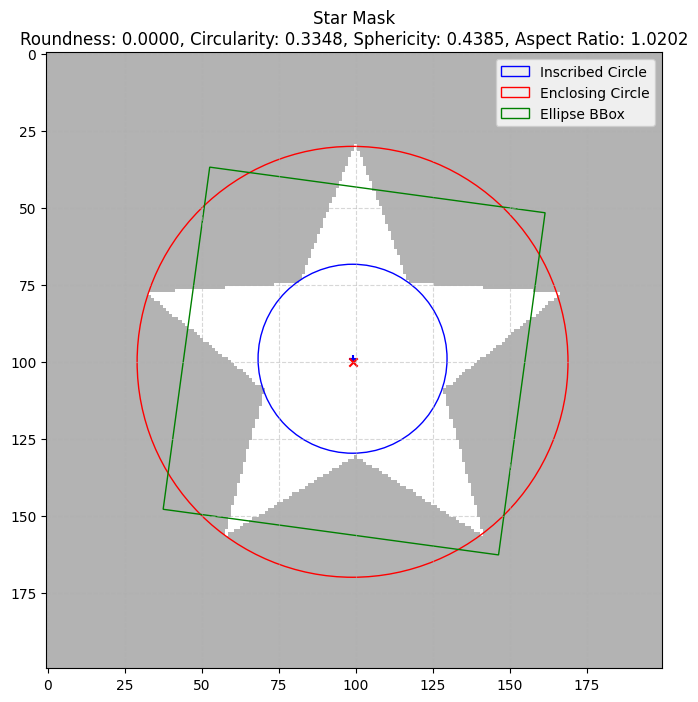

In [ ]:
shape = (200, 200)
masks_to_process = [
    ("Circle", create_circle_mask(shape, center=(100, 100), radius=50)),
    ("Ellipse", create_ellipse_mask(shape, center=(100, 100), radius_x=70, radius_y=40)),
    ("Rectangle", create_rectangle_mask(shape, top_left=(60, 40), bottom_right=(140, 160))),
    ("Square", create_square_mask(shape, top_left=(60, 60), size=80)),
    ("Triangle", create_triangle_mask(shape, v1=(40, 160), v2=(160, 160), v3=(100, 40))),
    ("Pentagon", create_pentagon_mask(shape, center=(100, 100), radius=60)),
    ("Star", create_star_mask(shape, center=(100, 100), outer_radius=70, inner_radius=30)),
]

# 1. Analyze all masks
results_list = []
for name, mask in masks_to_process:
    res = analyze_mask(mask)
    results_list.append({
        "name": name,
        "mask": mask,
        "results": res,
        "sphericity": res.get("sphericity", {}).get("val", 0.0)
    })

# 2. Sort by Sphericity (Descending)
sorted_results = sorted(results_list, key=lambda x: x["sphericity"], reverse=True)

# 3. Plot in sorted order
for item in sorted_results:
    plot_analysis_results(
        mask = item["mask"],
        results = item["results"],
        title_prefix = f"{item['name']} Mask",
    )